# --- Notebook : Modèle SVM - Cas de Tests de Régression ---

In [1]:
# --- Notebook : Modèle Linéaire - Cas de Tests de Régression ---
import ctypes
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
# === Chargement de la bibliothèque Rust compilée ===
lib = ctypes.CDLL("target/release/mymodel.dll")

In [4]:
lib.create_svm_regressor.argtypes = [
    ctypes.c_size_t,  # n_centers
    ctypes.c_double,  # gamma
    ctypes.c_double,  # epsilon
    ctypes.c_double   # C
]
lib.create_svm_regressor.restype = ctypes.c_void_p

lib.train_svm_regressor.argtypes = [
    ctypes.c_void_p,
    ctypes.POINTER(ctypes.c_double),
    ctypes.POINTER(ctypes.c_double),
    ctypes.c_size_t,
    ctypes.c_size_t
]

lib.predict_svm_regressor.argtypes = [
    ctypes.c_void_p,
    ctypes.POINTER(ctypes.c_double),
    ctypes.c_size_t
]
lib.predict_svm_regressor.restype = ctypes.c_double


In [5]:
def test_svm_regressor(lib, X, Y, name, n_centers=10, gamma=1.0, epsilon=0.1, C=1.0):
    print(f"\n--- {name} ---")

    X = X.astype(np.float64)
    Y = Y.astype(np.float64)
    X_flat = X.flatten()
    
    # Création du modèle
    model = lib.create_svm_regressor(
        n_centers,
        gamma,
        epsilon,
        C
    )

    # Entraînement
    lib.train_svm_regressor(
        model,
        X_flat.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
        Y.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
        X.shape[0],
        X.shape[1]
    )

    # Prédiction
    predictions = []
    for i in range(len(X)):
        x = X[i]
        pred = lib.predict_svm_regressor(
            model,
            x.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
            X.shape[1]
        )
        predictions.append(pred)
        print(f"Exemple {i} : Prédit = {pred:.3f}, Vrai = {Y[i]}")

    # Affichage des résultats
    predictions = np.array(predictions)
    if X.shape[1] == 1:
        plt.figure()
        plt.title(name)
        plt.scatter(X[:, 0], Y, label="Vrai", color="blue")
        plt.plot(X[:, 0], predictions, label="Prédit", color="red")
        plt.legend()
        plt.grid(True)
        plt.show()
    else:
        plt.figure()
        plt.title(name)
        plt.scatter(range(len(Y)), Y, label="Vrai", color="blue")
        plt.plot(range(len(Y)), predictions, label="Prédit", color="red")
        plt.xlabel("Index")
        plt.ylabel("Valeur prédite")
        plt.legend()
        plt.grid(True)
        plt.show()



--- SVM Regression - Linear Simple 2D ---
Exemple 0 : Prédit = 2.000, Vrai = 2.0
Exemple 1 : Prédit = 4.000, Vrai = 4.0
Exemple 2 : Prédit = 6.000, Vrai = 6.0


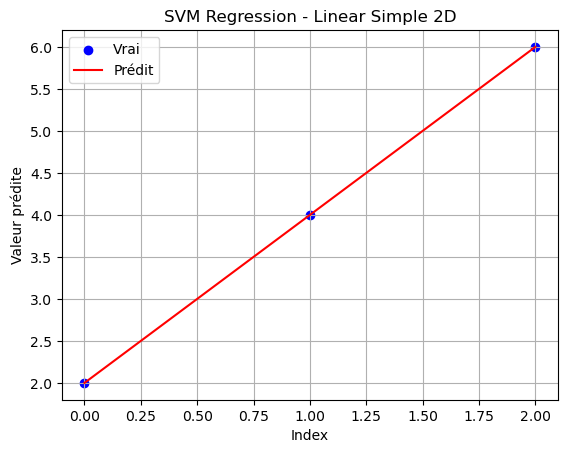

In [6]:
# === Cas 1 : Linear Simple 2D ===
X1 = np.array([
    [1, 1],
    [2, 2],
    [3, 3]
])
Y1 = np.array([2, 4, 6])
test_svm_regressor(lib, X1, Y1, "SVM Regression - Linear Simple 2D")


--- Non Linear Simple 2D ---
Exemple 0 : Prédit = 1.000, Vrai = 1.0
Exemple 1 : Prédit = 8.000, Vrai = 8.0
Exemple 2 : Prédit = 27.000, Vrai = 27.0


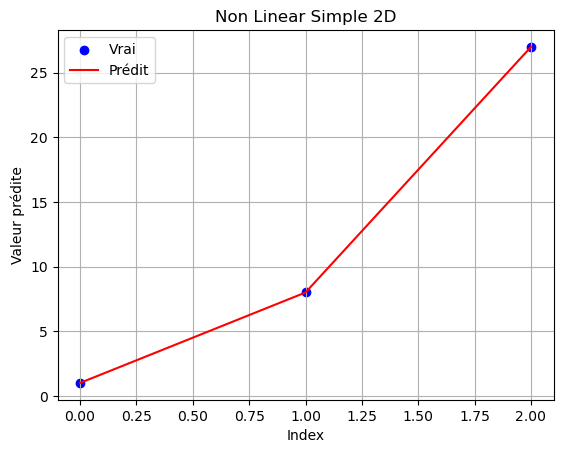

In [8]:
# === Cas 2 : Non Linear Simple 2D ===
X2 = np.array([
    [1, 1],
    [2, 2],
    [3, 3]
])
Y2 = np.array([1, 8, 27])  # y = x^3

test_svm_regressor(lib, X2, Y2, "Non Linear Simple 2D")


--- Linear Simple 3D ---
Exemple 0 : Prédit = 3.000, Vrai = 3.0
Exemple 1 : Prédit = 6.000, Vrai = 6.0
Exemple 2 : Prédit = 9.000, Vrai = 9.0


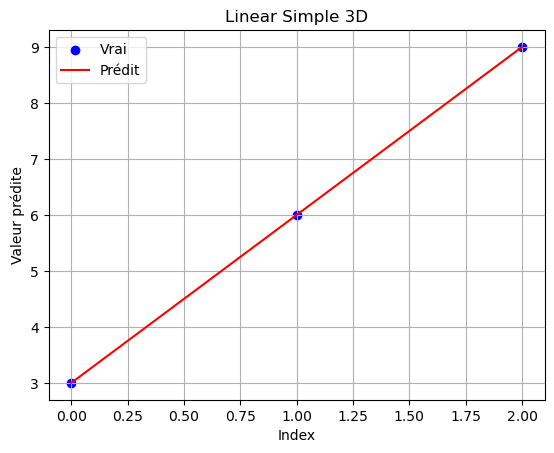

In [9]:
# === Cas 3 : Linear Simple 3D ===
X3 = np.array([
    [1, 1, 1],
    [2, 2, 2],
    [3, 3, 3]
])
Y3 = np.array([3, 6, 9])
test_svm_regressor(lib, X3, Y3, "Linear Simple 3D")


--- Linear Tricky 3D ---
Exemple 0 : Prédit = 14.000, Vrai = 14.0
Exemple 1 : Prédit = 28.000, Vrai = 28.0
Exemple 2 : Prédit = 42.000, Vrai = 42.0


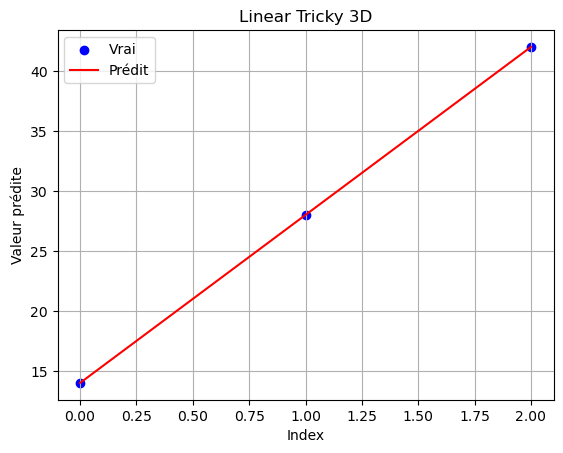

In [10]:
# === Cas 4 : Linear Tricky 3D ===
X4 = np.array([
    [1, 2, 3],
    [2, 4, 6],
    [3, 6, 9]
])
Y4 = np.array([14, 28, 42])
test_svm_regressor(lib, X4, Y4, "Linear Tricky 3D")


--- Non Linear Simple 3D ---
Exemple 0 : Prédit = 4.000, Vrai = 4.0
Exemple 1 : Prédit = 27.000, Vrai = 27.0
Exemple 2 : Prédit = 64.000, Vrai = 64.0


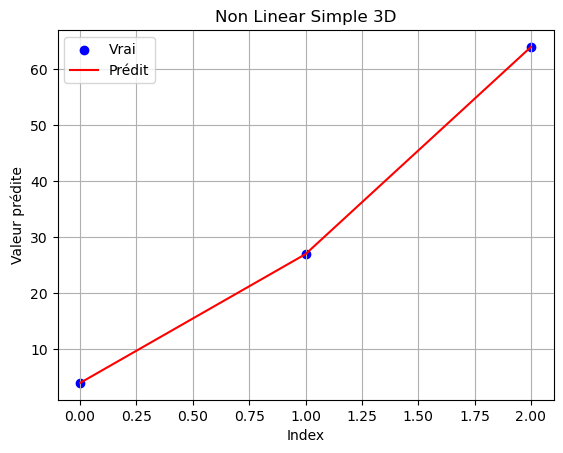

In [11]:
# === Cas 5 : Non Linear Simple 3D ===
X5 = np.array([
    [1, 2, 1],
    [2, 3, 2],
    [3, 4, 3]
])
Y5 = np.array([4, 27, 64])  # y = (x1 + x2)^2 * x3
test_svm_regressor(lib, X5, Y5, "Non Linear Simple 3D")


--- Régression simple ---
Exemple 0 : Prédit = 2.883, Vrai = 2.882199986327818
Exemple 1 : Prédit = 2.683, Vrai = 2.6823069459628472
Exemple 2 : Prédit = -0.484, Vrai = -0.49274741511121967
Exemple 3 : Prédit = 1.984, Vrai = 1.9829800141941778
Exemple 4 : Prédit = 0.316, Vrai = 0.30903243786515455
Exemple 5 : Prédit = 0.049, Vrai = 0.04221421483344967
Exemple 6 : Prédit = -0.967, Vrai = -0.9755933961571941
Exemple 7 : Prédit = 2.386, Vrai = 2.3855806667936807
Exemple 8 : Prédit = -0.117, Vrai = -0.12419542093398706
Exemple 9 : Prédit = 1.227, Vrai = 1.224613947405567
Exemple 10 : Prédit = 1.272, Vrai = 1.2695355629538012
Exemple 11 : Prédit = 0.451, Vrai = 0.44546784265092265
Exemple 12 : Prédit = 2.162, Vrai = 2.16143949955386
Exemple 13 : Prédit = 0.128, Vrai = 0.12051912847457436
Exemple 14 : Prédit = -0.768, Vrai = -0.7767522548871235
Exemple 15 : Prédit = 1.687, Vrai = 1.6852205188452865
Exemple 16 : Prédit = 1.174, Vrai = 1.1714328735928512
Exemple 17 : Prédit = 2.405, Vrai = 2.

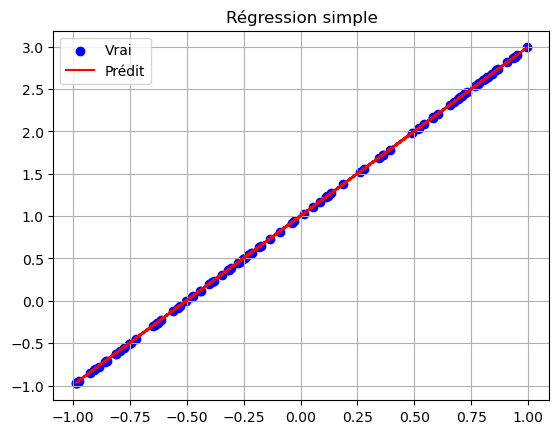

In [12]:
# === Régression simple ===
X = np.random.uniform(-1, 1, (100, 1))
Y = 2 * X[:, 0] + 1
test_svm_regressor(lib, X, Y, "Régression simple")